In [2]:
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt
#tsa为Time Series analysis缩写
import statsmodels.api as sm
import scipy.stats as scs
from arch import arch_model
#画图模块
import matplotlib.pyplot as plt
import matplotlib as mpl
#正常显示画图时出现的中文以及负号
from pylab import mpl
#设置了 matplotlib 使用 "SimHei" 字体作为默认的无衬线字体
mpl.rcParams['font.sans-serif']=['SimHei']
#设置了 matplotlib 在坐标轴上显示负号时不使用 Unicode 编码
mpl.rcParams['axes.unicode_minus']=False


ModuleNotFoundError: No module named 'statsmodels'

In [26]:
#定义画图函数
def ts_plot(data,lags=None,title=''):
    if not isinstance(data,pd.Series):
        data=pd.Series(data)
    #定义了 ts_plot 函数，并且接受三个参数：data，lags 和 title。
    #data 参数可以是一个 Pandas Series 对象或一个可转换为 Series 的数据（如列表）。
    #如果 data 不是 Series 对象，则将其转换为 Series。
    #matplotlib有五种图画风格，包括bmh，ggplot，dark_background，fivethirtyeight和grayscale
    with plt.style.context('ggplot'):
        fig=plt.figure(figsize=(10,8))
        layout=(3,2)
        ts_ax=plt.subplot2grid(layout,(0,0),colspan=2)
        #ts_ax：位于网格布局的第一行第一列，跨越两列，用于显示时间序列图。
        acf_ax=plt.subplot2grid(layout,(1,0))
        #acf_ax：位于网格布局的第二行第一列，用于显示自相关系数图。
        pacf_ax=plt.subplot2grid(layout,(1,1))
        #pacf_ax：位于网格布局的第二行第二列，用于显示偏自相关系数图。
        qq_ax=plt.subplot2grid(layout,(2,0))
        #qq_ax：位于网格布局的第三行第一列，用于显示 QQ 图。
        pp_ax=plt.subplot2grid(layout,(2,1))
        #pp_ax：位于网格布局的第三行第二列，用于显示 pp 图。
    #这部分代码使用 plt.style.context('ggplot') 设置图表的风格为 'ggplot'。
    #然后创建了一个大小为 (10, 8) 的图表对象 fig，并定义了一个 (3, 2) 的网格布局 layout。
    #在该布局中，定义了 5 个子图对象：ts_ax、acf_ax、pacf_ax、qq_ax 和 pp_ax。
        data.plot(ax=ts_ax)
        #data.plot(ax=ts_ax) 绘制了时间序列图，并将其显示在 ts_ax 子图对象上。
        ts_ax.set_title(title+'时序图')
        #ts_ax.set_title(title+'时序图') 设置了 ts_ax 子图对象的标题为 title 加上 "时序图"。
        smt.graphics.plot_acf(data,lags=lags,ax=acf_ax,alpha=0.5)
        #smt.graphics.plot_acf(data,lags=lags,ax=acf_ax,alpha=0.5) 绘制了自相关系数图，并将其显示在 acf_ax 子图对象上。
        acf_ax.set_title('自相关系数')
        #acf_ax.set_title('自相关系数') 设置了 acf_ax 子图对象的标题为 "自相关系数"。
        smt.graphics.plot_pacf(data,lags=lags,ax=pacf_ax,alpha=0.5)
        #smt.graphics.plot_pacf(data,lags=lags,ax=pacf_ax,alpha=0.5) 绘制了偏自相关系数图，并将其显示在 pacf_ax 子图对象上。
        pacf_ax.set_title('偏自相关系数')
        #pacf_ax.set_title('偏自相关系数') 设置了 pacf_ax 子图对象的标题为 "偏自相关系数"。
        sm.qqplot(data,line='s',ax=qq_ax)
        qq_ax.set_title('QQ图')
        scs.probplot(data,sparams=(data.mean(),data.std()),plot=pp_ax)
        #scs.probplot(data,sparams=(data.mean(),data.std()),plot=pp_ax) 绘制了 pp 图，并将其显示在 pp_ax 子图对象上。
        pp_ax.set_title('pp图')
        #这部分代码使用传入的数据 data 绘制了时间序列图，并在 ts_ax 上显示。
        #然后，使用 smt.graphics.plot_acf 和 smt.graphics.plot_pacf 分别绘制了自相关系数和偏自相关系数的图，并在相应的子图上显示。
        #接下来，使用 sm.qqplot 绘制了 QQ 图，并在 qq_ax 上显示。
        #最后，使用 scs.probplot 绘制了 pp 图，并在 pp_ax 上显示。
        plt.tight_layout()
    return
#这部分代码使用 plt.tight_layout() 调整子图的布局，使它们紧凑显示。然后，函数返回。

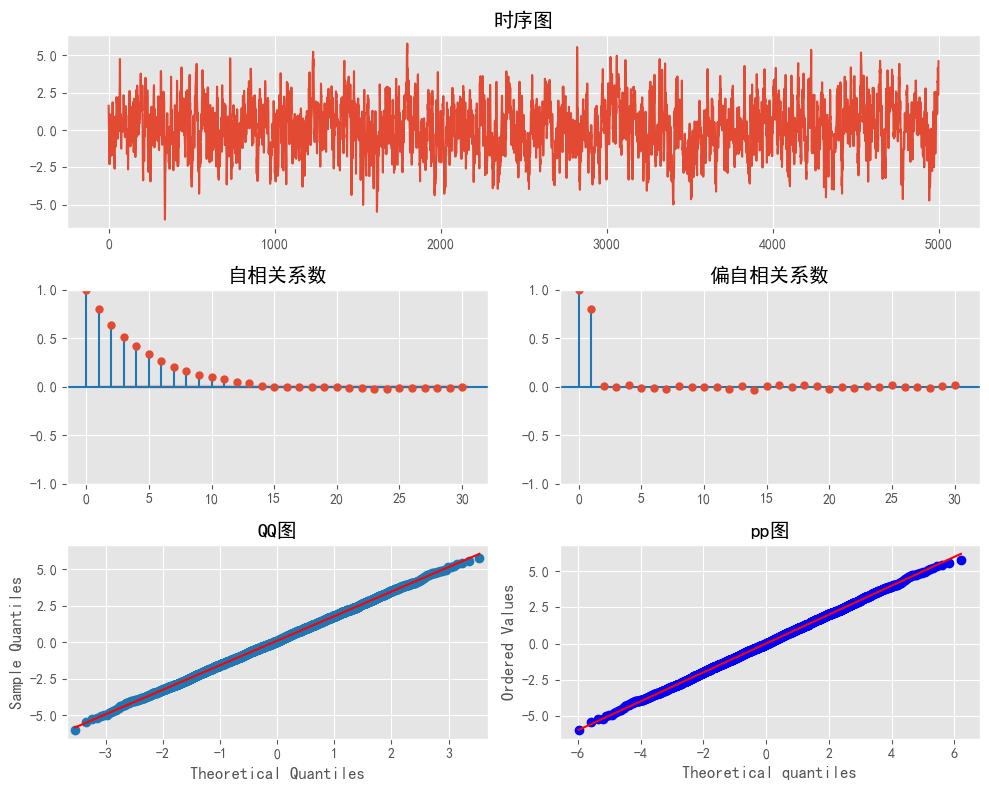

In [34]:
# 模拟AR(1)过程
#设置随机种子
np.random.seed(1)
#模拟次数
n=5000
#AR模型参数
a=0.8
#扰动项为正太分布
x=w=np.random.normal(size=n)
for t in range(1,n):
    x[t]=a*x[t-1]+w[t]
#画图
ts_plot(x,lags=30)
plt.show()

In [37]:
#估计数据的AR模型参数和滞后阶数
def simu_ar(data,a,maxlag=30,true_order=1):
    #'''data:要拟合的数据；a为参数,可以为列表；maxlag:最大滞后阶数'''
    #拟合AR(P)模型
    result=smt.AR(data).fit(maxlag=maxlag,ic='aic',trend='nc')
    #选择滞后阶数
    est_order=smt.AR(data).select_order(maxlag=maxlag,ic='aic',trend='nc')
    #参数选择标准ic：有四个选择{‘aic’，‘bic’，‘hqic’，‘t-stat’}
    #趋势项：trend：c是包含常数项，nc不包含常数项
    #打印结果
    print(f'参数估计值:{result.params.round(2)},估计的滞后性阶数:{est_order}')
    print(f'真实参数值:{a},真实滞后阶数:{true_orderorder}')
simu_ar(x,a=0.8)

NotImplementedError: AR has been removed from statsmodels and replaced with statsmodels.tsa.ar_model.AutoReg.

In [43]:
# Select best lag order for hs300 returns
import tushare as ts
token='598eb3c437b4143dde41a08f283e909b5cce0154bb923c346d4c6e58'
pro=ts.pro_api(token)
df=pro.index_daily(ts_code='000001.SZ')
df.index=pd.to_datetime(df.trade_date)
del df.index.name
df=df.sort_index()
df['ret']=np.log(df.close/df.close.shift(1))
max_lag = 30
Y=df.ret.dropna()
ts_plot(Y,lags=max_lag,title='沪深300')
result = smt.AR(Y.values).fit(maxlag=max_lag, ic='aic', trend='nc')
est_order = smt.AR(Y.values).select_order(maxlag=max_lag, 
            ic='aic', trend='nc')
print(f'沪深300拟合AR模型的参数：{result.params.round(2)}')
print(f'沪深300拟合AR模型的最佳滞后阶数 {est_order}')

Exception: 抱歉，您没有访问该接口的权限，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。